<a href="https://colab.research.google.com/github/shivraj2006/unsupervised_Learning/blob/main/Unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#python dependencies
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
data = pd.read_csv("/content/Mall_Customers.csv")
print("5 rows: ")
print(data.head())

print("Size of data")
print(data.shape)

print("Discription")
print(data.describe())

print(data.info())

print(data.isnull().sum())

5 rows: 
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Size of data
(200, 5)
Discription
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.25

In [ ]:
X = data[['Annual Income (k$)','Spending Score (1-100)']]

In [ ]:
print(X)

NameError: name 'X' is not defined

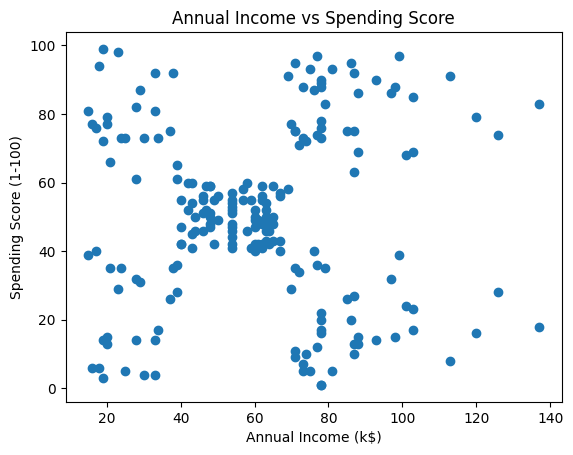

In [ ]:
plt.scatter(X['Annual Income (k$)'],X['Spending Score (1-100)'])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")
plt.show()

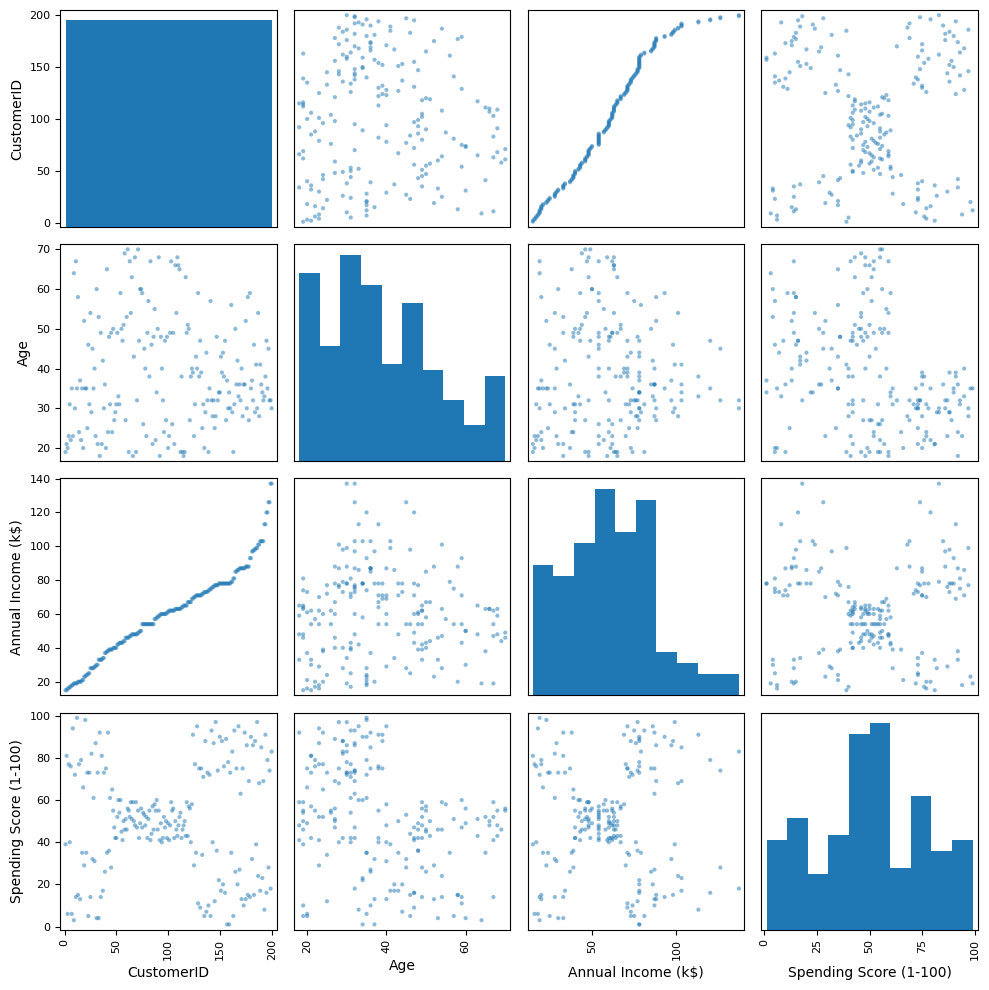

In [ ]:
numeric_data = data.select_dtypes(include='number')
pd.plotting.scatter_matrix(numeric_data, figsize=(10, 10))
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# X = data[['Annual Income (k$)','Spending Score (1-100)']]
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

In [ ]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled_df.head())

   Annual Income (k$)  Spending Score (1-100)
0           -1.738999               -0.434801
1           -1.738999                1.195704
2           -1.700830               -1.715913
3           -1.700830                1.040418
4           -1.662660               -0.395980


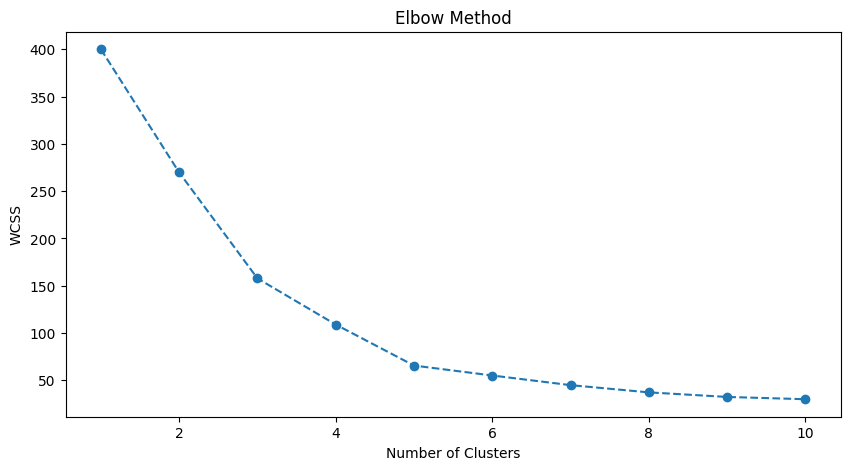

29.981897788243703


In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i,n_init=10,random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)
plt.figure(figsize=(10,5))
plt.plot(range(1,11),wcss,marker='o',linestyle='--')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()
inter = kmeans.inertia_
print(inter)


In [ ]:
KMEAN = KMeans(n_clusters=5,n_init=10,random_state=42)
KMEAN.fit(X_scaled)
labels = KMEAN.labels_
print(labels)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


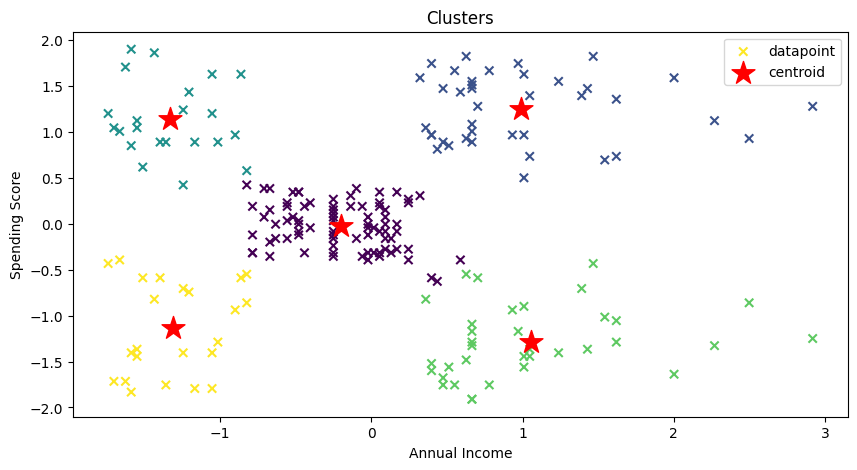

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=KMEAN.labels_,marker="x",label="datapoint")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Clusters")
plt.scatter(
    KMEAN.cluster_centers_[:,0],
    KMEAN.cluster_centers_[:,1],
    marker="*",s=300,c="red",label="centroid")
plt.legend()
plt.show()

In [ ]:
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 17.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2154563 sha256=60bd9919f794e3617499800651f5504cdd043f7377b36317d5fae421c2ba004e
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built scikit-learn-extra


In [ ]:
import pandas as pd
dict1 = {'Age' : [25, 23, 26, 48, 34],
         'Salary' : [22000, 25000, 56000, 50000, 45000]
         }
df = pd.DataFrame(dict1)

from sklearn_extra.cluster import KMedoids
kmedoids = KMedoids(n_clusters=3, random_state=42)
model = kmedoids.fit(df)
df['Clusters'] = kmedoids.labels_
print(df)
print("Medoids")
print(df.iloc[kmedoids.medoid_indices_])


   Age  Salary  Clusters
0   25   22000         2
1   23   25000         2
2   26   56000         1
3   48   50000         1
4   34   45000         0
Medoids
   Age  Salary  Clusters
4   34   45000         0
3   48   50000         1
1   23   25000         2


In [ ]:
import pandas as pd
data = pd.read_csv("/content/Mall_Customers.csv")

dict = {'Age' : data['Age'],
         'Salary' : data['Annual Income (k$)']
         }
df = pd.DataFrame(dict)

from sklearn_extra.cluster import KMedoids
kmedoids = KMedoids(n_clusters=5, random_state=42)
model = kmedoids.fit(df)
df['Clusters'] = kmedoids.labels_
print(df)
print("Medoids")
print(df.iloc[kmedoids.medoid_indices_])

     Age  Salary  Clusters
0     19      15         4
1     21      15         4
2     20      16         4
3     23      16         4
4     31      17         4
..   ...     ...       ...
195   35     120         3
196   45     126         3
197   32     126         3
198   32     137         3
199   30     137         3

[200 rows x 3 columns]
Medoids
     Age  Salary  Clusters
126   43      71         0
63    54      47         1
132   25      72         2
180   37      97         3
25    29      28         4


Text(0.5, 1.0, 'Clusters')

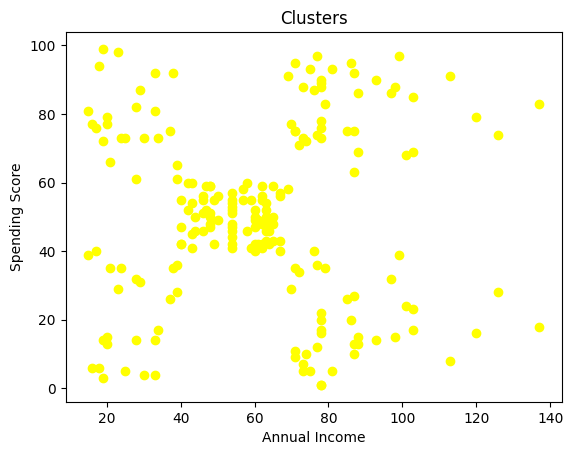

In [ ]:
import matplotlib.pyplot as plt
x = data[['Annual Income (k$)', 'Spending Score (1-100)']]
plt.scatter(x['Annual Income (k$)'],x['Spending Score (1-100)'], c='yellow',marker='o',label='datapoint')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Clusters")

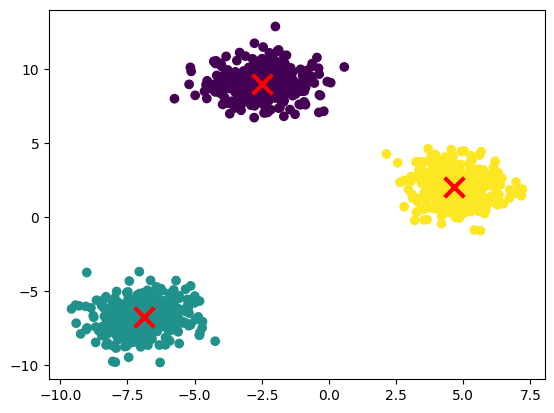

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

x, y = make_blobs(n_samples=1000, centers=3, random_state=42, n_features=2)
mbk = MiniBatchKMeans(n_clusters=3, random_state=42, batch_size=100)
mbk.fit(x)

plt.scatter(x[:, 0], x[:, 1], c=mbk.labels_, cmap='viridis')
plt.scatter(mbk.cluster_centers_[:, 0], mbk.cluster_centers_[:, 1], marker='x', s=200, linewidths=3, color='r')
plt.show()

Cluster Centers:
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


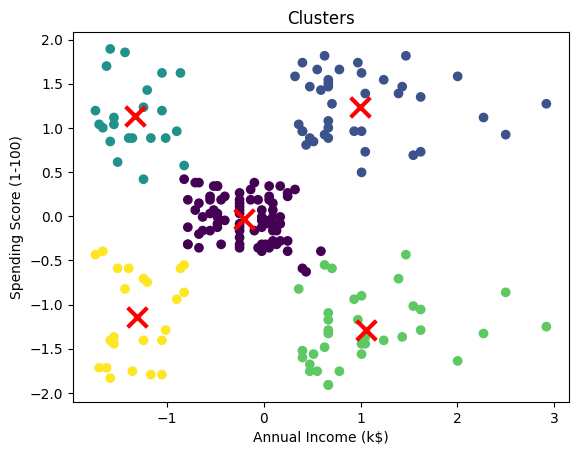

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("/content/Mall_Customers.csv")

x = data[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

kmeans = KMeans(
    n_clusters=5,
    init = 'k-means++',
    n_init=10,
    random_state=42
)

kmeans.fit(X_scaled)

data["Cluster"] = kmeans.labels_

print("Cluster Centers:")
print(kmeans.cluster_centers_)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=data["Cluster"], cmap="viridis")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="x", s=200, linewidths=3, color="r")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Clusters")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

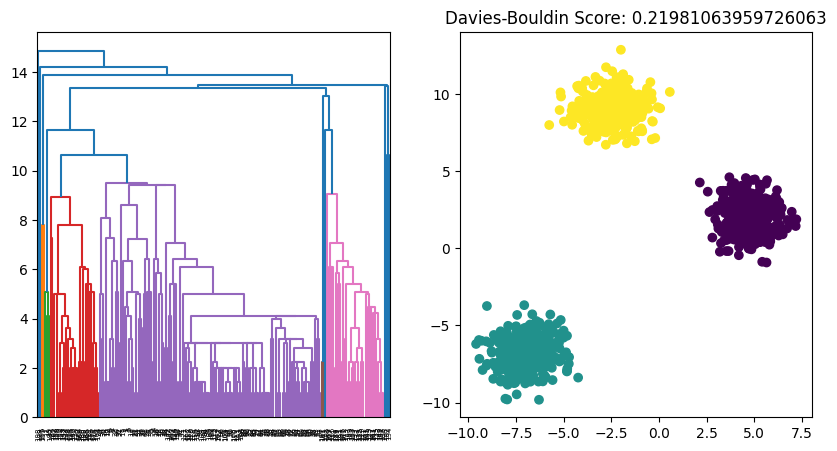

In [ ]:
from numpy import savez_compressed
from sklearn.metrics import davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs
x, _ = make_blobs(n_samples=1000, centers=3, random_state=42, n_features=2)
labels = AgglomerativeClustering(n_clusters=3).fit_predict(x)
score = davies_bouldin_score(x, labels)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
dendrogram(linkage(X,'single'))
plt.subplot(1,2,2)
plt.scatter(x[:,0], x[:,1], c=labels, cmap='viridis')
plt.title(f'Davies-Bouldin Score: {score}')
plt.show()